In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


desaturated_deep = sns.color_palette("deep", as_cmap=False, desat=0.7)  # 0.7 = 70% saturation
sns.set_theme(style="whitegrid", palette=desaturated_deep)

In [ ]:
def plot_ablation(df, col1, col2, prune_amt, name):

    color = desaturated_deep[1] if prune_amt == 0.98 else desaturated_deep[0]
    dftmp = df[df["PRUNE_AMT"] == prune_amt]
    plt.figure()
    sns.boxplot(x=col1, y=col2, data=dftmp, color=color)
    # medians = df.groupby("N_EPOCH_PRUNE")["Accuracy"].median().reset_index()

    # # Sort by x if needed
    # medians = medians.sort_values("N_EPOCH_PRUNE")
    # # Get the categories in order as they appear on the x-axis
    # categories = medians["N_EPOCH_PRUNE"].tolist()

    # # Get the x-tick positions (0, 1, 2, etc.) for the categories
    # x_positions = range(len(categories))

    # # Plot the line connecting medians
    # plt.plot(
    #     x_positions,
    #     medians["Accuracy"],
    #     color=color,
    #     marker="o",
    #     linestyle="--",
    # )

    if col1 == "N_PRE":
        plt.xlabel("N_PRE")
    elif col1 == "N_ITER":
        plt.xlabel("N_ITER")
    elif col1 == "N_EPOCH_PRUNE":
        plt.xlabel("N_PRUNE")

    plt.ylabel("Accuracy")
    plt.savefig(f"./img/figv3_{name}.png", bbox_inches="tight")


df = pd.read_csv("./scores_resnet20cifar10_ablation.csv")
df = df[df["Accuracy"] > 0.6]
print(df.columns)

plot_ablation(df, "N_PRE", "Accuracy", 0.9, "3a")
plot_ablation(df, "N_ITER", "Accuracy", 0.9, "3b")
plot_ablation(df, "N_EPOCH_PRUNE", "Accuracy", 0.9, "3c")
plot_ablation(df, "N_PRE", "Accuracy", 0.98, "3d")
plot_ablation(df, "N_ITER", "Accuracy", 0.98, "3e")
plot_ablation(df, "N_EPOCH_PRUNE", "Accuracy", 0.98, "3f")


In [ ]:
from generate_results import load_pruned_weights, get_accuracy, compute_sparsity
import sys
import torch
import numpy as np
import pandas as pd

sys.path.append("../")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from tests.models import get_model
from tests.datasets import get_dataset

model = get_model("resnet20", "cifar10", checkpoint_dir=None)
tmp = get_dataset("cifar10", "resnet20", "../data")
trainset = tmp[0]
testset = tmp[1]
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4)

path_causal = "/home/think-server/Documents/cpn/checkpoints/resnet20_cifar10/resnet20_cifar10_1/resnet20_cifar10_causalpruner_10_10_1_0.001_0.9/model.prune.final.ckpt"
model = load_pruned_weights(model, path_causal).to(device)
model.eval()

acc_causal = get_accuracy(model, testloader)

weights_causal = []
for name,param in model.named_parameters():
    if "weight" in name:
        weights_causal.append(param.data.cpu().numpy().flatten())

weights_causal = np.concatenate(weights_causal, axis=0)
weights_causal = weights_causal[weights_causal != 0]


path_mag = "/home/think-server/Documents/cpn/checkpoints/resnet20_cifar10/resnet20_cifar10_1/resnet20_cifar10_magpruner_0.9/model.prune.9.ckpt"
model = load_pruned_weights(model, path_mag).to(device)
model.eval()

acc_mag = get_accuracy(model, testloader)

weights_mag = []
for name, param in model.named_parameters():
    if "weight" in name:
        weights_mag.append(param.data.cpu().numpy().flatten())

weights_mag = np.concatenate(weights_mag, axis=0)
weights_mag = weights_mag[weights_mag != 0]

weights = np.concatenate([weights_causal, weights_mag], axis=0)
keys = np.concatenate([np.ones(len(weights_causal)), np.zeros(len(weights_mag))], axis=0)
df = pd.DataFrame({"weights": weights, "Algorithm (Acc)": keys})
df['Algorithm (Acc)'] = df['Algorithm (Acc)'].replace(0, f"Mag Pruning ({acc_mag*100:0.2f})")
df['Algorithm (Acc)'] = df['Algorithm (Acc)'].replace(1, f"Causal Pruning ({acc_causal*100:0.2f})")

plt.figure()
sns.histplot(df, x="weights", hue="Algorithm (Acc)", bins=100, kde=True, common_norm=True)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.xlim(-0.5, 0.5)
plt.savefig("./img/figv3_1b.png", bbox_inches="tight")

Text(0.5, 0, 'Eigenvalue Index')

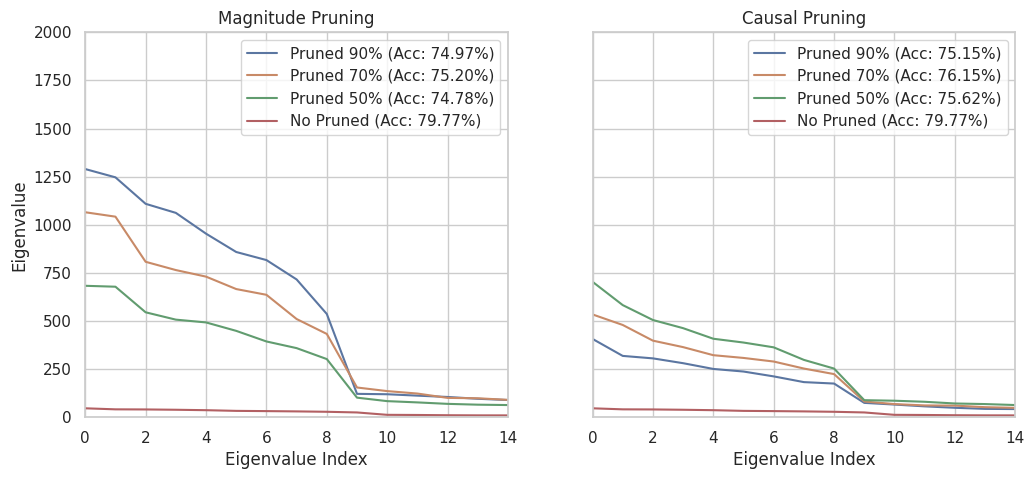

In [6]:
import itertools

# Create subplots with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

model_name = "lenet"
list_prune_amt = [0.9, 0.7, 0.5, 0]

dict_acc = {
    "causal": {
        0.9: 0.7515,
        0.7: 0.7615,
        0.5: 0.7562
    },
    "mag": {
        0.9: 0.7497,
        0.7: 0.7520,
        0.5: 0.7478,
    },
    "noprune": {
        0: 0.7977,
    }
}

# Left plot: Magnitude pruning
ax_left = axes[0]
list_method_name = ["mag", "noprune"]
for method_name, prune_amt in itertools.product(list_method_name, list_prune_amt):
    # Skip noprune for non-zero prune amounts
    if method_name == "noprune" and prune_amt != 0:
        continue
    if prune_amt == 0 and method_name != "noprune":
        continue

    fname = f"./eigvals/eigenvals_{model_name}_{method_name}_{prune_amt}.txt"
    eigenvals = np.loadtxt(fname)

    label_name = f"Pruned {prune_amt*100:.0f}% (Acc: {dict_acc[method_name][prune_amt]*100:.2f}%)"
    if prune_amt == 0:
        label_name = "No Pruned (Acc: 79.77%)"

    sns.lineplot(
        x=range(15), y=eigenvals[::-1][:15], label=label_name, ax=ax_left
    )

ax_left.set_title("Magnitude Pruning")
ax_left.legend()
ax_left.set_xlim(0, 14)
ax_left.set_ylim(0, 1300)
ax_left.set_xlabel("Eigenvalue Index")
ax_left.set_ylabel("Eigenvalue")

# Right plot: Causal pruning
ax_right = axes[1]
list_method_name = ["causal", "noprune"]
for method_name, prune_amt in itertools.product(list_method_name, list_prune_amt):
    # Skip noprune for non-zero prune amounts
    if method_name == "noprune" and prune_amt != 0:
        continue
    if prune_amt == 0 and method_name != "noprune":
        continue

    fname = f"./eigvals/eigenvals_{model_name}_{method_name}_{prune_amt}.txt"
    eigenvals = np.loadtxt(fname)

    label_name = f"Pruned {prune_amt*100:.0f}% (Acc: {dict_acc[method_name][prune_amt]*100:.2f}%)"
    if prune_amt == 0:
        label_name = "No Pruned (Acc: 79.77%)"

    sns.lineplot(
        x=range(15), y=eigenvals[::-1][:15], label=label_name, ax=ax_right
    )

ax_right.set_title("Causal Pruning")
ax_right.legend()
ax_right.set_xlim(0, 14)
ax_right.set_ylim(0, 2000)
ax_right.set_xlabel("Eigenvalue Index")

# plt.tight_layout()
# plt.savefig("./img/figv3_1cd_combined.png", bbox_inches="tight")
# plt.show()

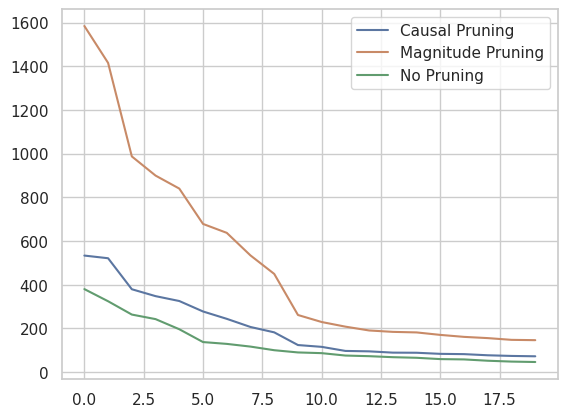

In [7]:
import numpy as np

list_method_prune = [
    ("causal", 0.9),
    ("mag", 0.9),
    ("noprune", 0),
]

map_legend = {
    "causal": "Causal Pruning",
    "mag": "Magnitude Pruning",
    "noprune": "No Pruning",
}

model_name = "resnet18"
for method_name, prune_amt in list_method_prune:
    fname = f"./eigvals/eigenvals_{model_name}_{method_name}_{prune_amt}.txt"
    eigenvals = np.loadtxt(fname)

    sns.lineplot(x=range(20), y=eigenvals[::-1][:20], label=f"{map_legend[method_name]}")

plt.legend()
plt.savefig(f"./img/figv3_4e.png", bbox_inches="tight")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import pyvista as pv

# pv.set_jupyter_backend("trame")
# pv.set_plot_theme("default")

# x = np.load("../alpha_grid.npy")
# y = np.load("../beta_grid.npy")
# z = np.load("../loss_grid.npy")
# z = np.log(2 + np.log(z))
# # z = (z - np.min(z)) / (np.max(z) - np.min(z))


# grid = pv.StructuredGrid(x,y,z)
# grid.plot(cmap="jet")

In [6]:
# import numpy as np
# import pyvista as pv

# # # 1) Build your toy loss‐landscape
# # nx, ny = 300, 300
# # x = np.linspace(-5, 5, nx)
# # y = np.linspace(-5, 5, ny)
# # x, y = np.meshgrid(x, y)
# # noise = 0.3 * np.random.randn(nx, ny)
# # z = x**2 + y**2 + noise
# # zmin, zmax = float(z.min()), float(z.max())

# # # 2) Wrap into a StructuredGrid
# # x3 = x.reshape(nx, ny, 1)
# # y3 = y.reshape(nx, ny, 1)
# # z3 = z.reshape(nx, ny, 1)


# def plot_pyvista_loss_landscape(x3, y3, z3, zmin, zmax, path_save):
#     grid = pv.StructuredGrid(x3, y3, z3)
#     grid["Elevation"] = grid.points[:, 2]

#     # 3) Build a coolwarm LUT locked to [zmin,zmax]
#     lut = pv.LookupTable(cmap="coolwarm", n_values=256)
#     lut.scalar_range = (zmin, zmax)

#     # 4) Plot normally, then overwrite the mapper
#     p = pv.Plotter(off_screen=True)
#     p.set_background("white")

#     actor = p.add_mesh(
#         grid,
#         scalars="Elevation",
#         cmap="coolwarm",  # choose the map family
#         clim=(zmin, zmax),  # lock the mapper’s range
#         show_scalar_bar=False,
#         smooth_shading=True,
#         ambient=0.2,
#         diffuse=0.7,
#         specular=0.5,
#         specular_power=30,
#     )

#     p.show_grid(
#         color="lightgray",  # grid line colour
#         # line_width=1,  # grid line thickness
#         grid="back",  # draw on the “back” walls
#         xlabel="X",
#         ylabel="Y",
#         zlabel="Z",  # optional axis labels
#     )

#     # wireframe on top
#     p.add_mesh(
#         grid,
#         color="black",
#         style="wireframe",
#         line_width=0.5,
#         opacity=0.4,   # fade it if you like
#     )


#     # 5) Grab the vtkMapper and inject our LUT + force full-range
#     mapper = actor.mapper
#     mapper.SetLookupTable(lut)  # your custom LUT
#     mapper.SetUseLookupTableScalarRange(True)  # honor lut.scalar_range
#     mapper.SetScalarRange(zmin, zmax)  # enforce full/data range

#     # 6) Camera & save
#     p.camera_position = "iso"
#     p.show(screenshot=path_save)
#     print(f"Wrote {path_save}")

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import pyvista as pv
# import itertools

# pv.set_jupyter_backend("static")

# model_name = "lenet"
# list_method_name = ["causal", "mag", "noprune"]
# list_prune_amt = [0.9, 0.7, 0.5, 0]
# # list_model_name = ["lenet", "resnet20"]
# for method_name, prune_amt in itertools.product(list_method_name, list_prune_amt):
#     # Skip noprune for non-zero prune amounts
#     if method_name == "noprune" and prune_amt != 0:
#         continue
#     if prune_amt == 0 and method_name != "noprune":
#         continue
#     print(f"Computing eigenvalues for {model_name} with {method_name} and {prune_amt}")

#     path_alpha = f"/home/think-server/Documents/cpn/results/loss_landscape/{model_name}_{method_name}_{prune_amt}/alpha_grid.npy"
#     path_beta = f"/home/think-server/Documents/cpn/results/loss_landscape/{model_name}_{method_name}_{prune_amt}/beta_grid.npy"
#     path_loss = f"/home/think-server/Documents/cpn/results/loss_landscape/{model_name}_{method_name}_{prune_amt}/loss_grid.npy"
#     x = np.load(path_alpha)
#     y = np.load(path_beta)
#     z = np.load(path_loss)
#     z = np.log(z)

#     path_save = f"/home/think-server/Documents/cpn/results/loss_landscape/{model_name}_{method_name}_{prune_amt}/loss_landscape.png"

#     a,b,c,d = 5,-5,5,-5
#     x = x[a:b,c:d,np.newaxis]
#     y = y[a:b,c:d,np.newaxis]
#     z = z[a:b,c:d,np.newaxis]
#     zmin = z.min()
#     zmax = z.max()

#     plot_pyvista_loss_landscape(x, y, z, zmin, zmax, path_save)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("/home/think-server/Documents/cpn/results/exp02_results_lenet.csv")

print(df.columns)
df["Algorithm"] = df["path_name"]
df["Algorithm"] = df["Algorithm"].replace("causal", "Causal Pruning")
df["Algorithm"] = df["Algorithm"].replace("mag", "Mag. Pruning")
df["Algorithm"] = df["Algorithm"].replace("base", "No Pruning")
df["log(noise)"] = np.log(df["noise_level"])
df["log(relative-loss)"] = np.log(df["relative_loss"])
df["log(loss)"] = np.log(df["loss"])

plt.figure()
sns.lineplot(x="log(noise)", y="log(relative-loss)", hue="Algorithm", data=df, marker="o")
plt.xlim(-5, max(df["log(noise)"] + 1e-3))
plt.xlabel("log(noise)")
plt.ylabel("log(relative-loss)")
plt.savefig("./img/figv3_4a.png", bbox_inches="tight")

causal_base_loss = 0.7778579792022705
mag_base_loss = 0.7890931664466858
base_base_loss = 0.7238237194061279

# Add a column to the dataframe called "base_loss"
df["base_loss"] = df["path_name"].apply(
    lambda x: causal_base_loss if "causal" in x else mag_base_loss if "mag" in x else base_base_loss
)

# Add a column to the dataframe called "relative_loss"
df["diff_loss"] = df["loss"] - df["base_loss"]

# for each noise level, plot the maximum(diff_loss)
tmp = {
    "noise_level": [],
    "causal_max": [],
    "mag_max": [],
    "base_max": [],
}
for noise_level in df["noise_level"].unique():
    tmp["noise_level"].append(noise_level)
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "causal")
    tmp["causal_max"].append(df[flag_noise_alg]["diff_loss"].max())
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "mag")
    tmp["mag_max"].append(df[flag_noise_alg]["diff_loss"].max())
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "base")
    tmp["base_max"].append(df[flag_noise_alg]["diff_loss"].max())

tmp = pd.DataFrame(tmp)

# convert the columns causal_max, mag_max, base_max as rows with a new column called "Algorithm"
tmp = tmp.melt(id_vars=["noise_level"], var_name="Algorithm", value_name="diff_loss")
# remove the rows where noise_level is 0.1
tmp = tmp[tmp["noise_level"] != tmp["noise_level"].max()]

plt.figure()
sns.lineplot(x="noise_level", y="diff_loss", hue="Algorithm", data=tmp, marker="o")
plt.xlabel("Noise Level")
plt.ylabel("Loss Difference")
plt.savefig("img/figv3_4b.png", bbox_inches="tight")

Index(['path_name', 'noise_level', 'loss', 'relative_loss'], dtype='object')


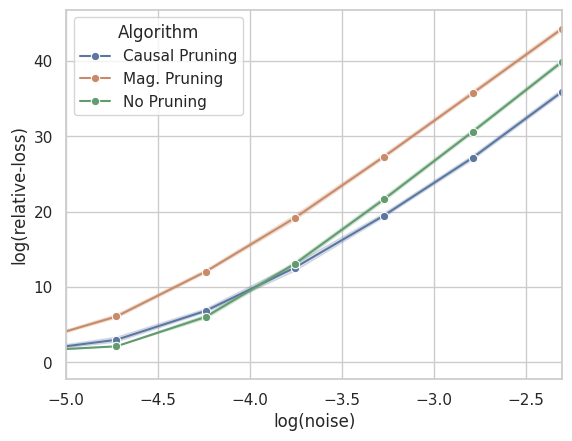

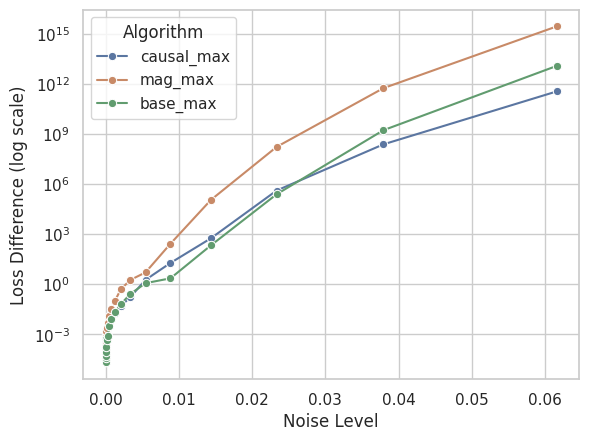

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# df = pd.read_csv("/home/think-server/Documents/cpn/results/exp02_results_lenet.csv")
df = pd.read_csv("/home/think-server/Documents/cpn/results/exp02_results_resnet18.csv")

print(df.columns)
df['Algorithm'] = df['path_name']
df["Algorithm"] = df["Algorithm"].replace("causal", "Causal Pruning")
df["Algorithm"] = df["Algorithm"].replace("mag", "Mag. Pruning")
df["Algorithm"] = df["Algorithm"].replace("base", "No Pruning")
df['log(noise)'] = np.log(df['noise_level'])
df['log(relative-loss)'] = np.log(df['relative_loss'])
df['log(loss)'] = np.log(df['loss'])

plt.figure()
sns.lineplot(x="log(noise)", y="log(relative-loss)", hue="Algorithm",data=df, marker="o")
plt.xlim(-5, max(df['log(noise)']+1e-3))
plt.xlabel("log(noise)")
plt.ylabel("log(relative-loss)")
plt.savefig("./img/figv3_4c.png", bbox_inches="tight")

causal_base_loss = 0.3093517704963684
mag_base_loss = 0.311091425037384
base_base_loss = 0.29366001224517824

# Add a column to the dataframe called "base_loss"
df["base_loss"] = df["path_name"].apply(
    lambda x: causal_base_loss if "causal" in x else mag_base_loss if "mag" in x else base_base_loss
)

# Add a column to the dataframe called "relative_loss"
df["diff_loss"] = df["loss"] - df["base_loss"]

# for each noise level, plot the maximum(diff_loss)
tmp = {
    "noise_level": [],
    "causal_max": [],
    "mag_max": [],
    "base_max": [],
}
for noise_level in df["noise_level"].unique():
    tmp["noise_level"].append(noise_level)
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "causal")
    tmp["causal_max"].append(df[flag_noise_alg]["diff_loss"].max())
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "mag")
    tmp["mag_max"].append(df[flag_noise_alg]["diff_loss"].max())
    flag_noise_alg = (df["noise_level"] == noise_level) & (df["path_name"] == "base")
    tmp["base_max"].append(df[flag_noise_alg]["diff_loss"].max())

tmp = pd.DataFrame(tmp)

# convert the columns causal_max, mag_max, base_max as rows with a new column called "Algorithm"
tmp = tmp.melt(id_vars=["noise_level"], var_name="Algorithm", value_name="diff_loss")
# remove the rows where noise_level is 0.1
tmp = tmp[tmp["noise_level"] != tmp["noise_level"].max()]

plt.figure()
sns.lineplot(x="noise_level", y="diff_loss", hue="Algorithm", data=tmp, marker="o")
plt.yscale("log")
plt.xlabel("Noise Level")
plt.ylabel("Loss Difference (log scale)")
plt.savefig("img/figv3_4d.png", bbox_inches="tight")